# Labour Force Data
Labour force status for adults with disabilities by disability type: https://open.canada.ca/data/en/dataset/92aeb8dc-c7ca-4f44-81df-fdaf289d23fd 

In [1]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
# Load data

labour_force = pd.read_csv("../data/raw/labour_force_with_disabilities/labourforcewithdisabilities.csv")
labour_force.head()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Total labour force,Number,223,units,0,v91886462,1.1.1.1.1.1,2338240.0,NaN,NaN,NaN,0
1,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Employed,Number,223,units,0,v91886463,1.1.1.1.1.2,1026910.0,NaN,NaN,NaN,0
2,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Unemployed,Number,223,units,0,v91886464,1.1.1.1.1.3,137450.0,NaN,NaN,NaN,0
3,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Not in labour force,Number,223,units,0,v91886465,1.1.1.1.1.4,1007660.0,NaN,NaN,NaN,0
4,2012,Canada,2016A000011124,Both sexes,"Total, 15 to 64 years",All disability types,"Total population, severity of disability",Participation rate,Percent,239,units,0,v91886466,1.1.1.1.1.5,53.6,NaN,NaN,NaN,1


In [3]:
labour_force.tail()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
151195,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized participation rate,Percent,239,units,0,v92037657,14.3.6.12.5.6,NaN,F,NaN,NaN,1
151196,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Employment Rate,Percent,239,units,0,v92037658,14.3.6.12.5.7,NaN,F,NaN,NaN,1
151197,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized employment rate,Percent,239,units,0,v92037659,14.3.6.12.5.8,NaN,F,NaN,NaN,1
151198,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Unemployment rate,Percent,239,units,0,v92037660,14.3.6.12.5.9,NaN,F,NaN,NaN,1
151199,2012,Nunavut,2016A000262,Females,55 to 64 years,Unknown disability type,Very Severe,Age standardized unemployment rate,Percent,239,units,0,v92037661,14.3.6.12.5.10,NaN,F,NaN,NaN,1


## EDA (on raw data)

In [4]:
labour_force.shape

(151200, 19)

In [5]:
labour_force.info()

<class 'pandas.DataFrame'>
RangeIndex: 151200 entries, 0 to 151199
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   REF_DATE             151200 non-null  int64  
 1   GEO                  151200 non-null  str    
 2   DGUID                151200 non-null  str    
 3   Sex                  151200 non-null  str    
 4   Age group            151200 non-null  str    
 5   Disability type      151200 non-null  str    
 6   Global Severity      151200 non-null  str    
 7   Labour force status  151200 non-null  str    
 8   UOM                  151200 non-null  str    
 9   UOM_ID               151200 non-null  int64  
 10  SCALAR_FACTOR        151200 non-null  str    
 11  SCALAR_ID            151200 non-null  int64  
 12  VECTOR               151200 non-null  str    
 13  COORDINATE           151200 non-null  str    
 14  VALUE                34597 non-null   float64
 15  STATUS               136535 

In [6]:
labour_force['Sex'].value_counts()

Sex
Both sexes    50400
Males         50400
Females       50400
Name: count, dtype: int64

In [7]:
labour_force.groupby('Sex')['VALUE'].sum().reset_index()

,Sex,VALUE
0,Both sexes,142140711.5
1,Females,73622904.4
2,Males,60797599.0


In [8]:
142140711.5 - (60797599.0+73622904.4)

7720208.099999994

In [9]:
labour_force['Age group'].value_counts()

Age group
Total, 15 to 64 years    25200
15 to 24 years           25200
25 to 34 years           25200
35 to 44 years           25200
45 to 54 years           25200
55 to 64 years           25200
Name: count, dtype: int64

In [10]:
labour_force['Global Severity'].value_counts()

Global Severity
Total population, severity of disability    30240
Mild                                        30240
Moderate                                    30240
Severe                                      30240
Very Severe                                 30240
Name: count, dtype: int64

In [11]:
labour_force['Disability type'].value_counts()

Disability type
All disability types           12600
Seeing                         12600
Hearing                        12600
Mobility                       12600
Flexibility                    12600
Dexterity                      12600
Pain                           12600
Learning                       12600
Memory                         12600
Developmental                  12600
Mental and/or psychological    12600
Unknown disability type        12600
Name: count, dtype: int64

In [12]:
labour_force['Labour force status'].value_counts()

Labour force status
Total labour force                     15120
Employed                               15120
Unemployed                             15120
Not in labour force                    15120
Participation rate                     15120
Age standardized participation rate    15120
Employment Rate                        15120
Age standardized employment rate       15120
Unemployment rate                      15120
Age standardized unemployment rate     15120
Name: count, dtype: int64

In [13]:
labour_force['UOM'].value_counts()

UOM
Percent    90720
Number     60480
Name: count, dtype: int64

In [14]:
# redundant because it contains the same info as labour_force['UOM']
labour_force['UOM_ID'].value_counts()

UOM_ID
239    90720
223    60480
Name: count, dtype: int64

In [15]:
# holds no useful info
labour_force['SCALAR_FACTOR'].value_counts()

SCALAR_FACTOR
units     151200
Name: count, dtype: int64

In [16]:
# holds no useful info
labour_force['SCALAR_ID'].value_counts()

SCALAR_ID
0    151200
Name: count, dtype: int64

In [17]:
# holds no useful info
labour_force['VECTOR'].value_counts()

VECTOR
v91886462    1
v91886463    1
v91886464    1
v91886465    1
v91886466    1
            ..
v92037657    1
v92037658    1
v92037659    1
v92037660    1
v92037661    1
Name: count, Length: 151200, dtype: int64

In [18]:
# holds no useful info
labour_force['COORDINATE'].value_counts()

COORDINATE
1.1.1.1.1.1       1
1.1.1.1.1.2       1
1.1.1.1.1.3       1
1.1.1.1.1.4       1
1.1.1.1.1.5       1
                 ..
14.3.6.12.5.6     1
14.3.6.12.5.7     1
14.3.6.12.5.8     1
14.3.6.12.5.9     1
14.3.6.12.5.10    1
Name: count, Length: 151200, dtype: int64

In [19]:
# Symbol legend: E use with caution, F too unreliable to be published
labour_force['STATUS'].value_counts()

STATUS
F    116603
E     19932
Name: count, dtype: int64

In [20]:
# holds no useful info
labour_force['DECIMALS'].value_counts()

DECIMALS
1    90720
0    60480
Name: count, dtype: int64

In [21]:
# 2. Condition 1: STATUS is 'F' but VALUE is NOT missing (not NaN)
f_but_has_value = labour_force[(labour_force['STATUS'] == 'F') & (labour_force['VALUE'].notnull())]

# 3. Condition 2: VALUE is missing (NaN) but STATUS is NOT 'F'
nan_but_not_f = labour_force[labour_force['VALUE'].isnull() & (labour_force['STATUS'] != 'F')]

# 4. Print individual condition results
print(f"Rows where STATUS == 'F' but VALUE is present: {len(f_but_has_value)}")
print(f"Rows where VALUE is NaN but STATUS != 'F':     {len(nan_but_not_f)}")

# 5. Print aggregate counts for full verification
print("\n--- Aggregate Count Check ---")
print(f"Total rows in dataset:             {len(labour_force):,}")
print(f"Total rows with STATUS == 'F':      {(labour_force['STATUS'] == 'F').sum():,}")
print(f"Total rows with VALUE as NaN:      {labour_force['VALUE'].isnull().sum():,}")

Rows where STATUS == 'F' but VALUE is present: 0
Rows where VALUE is NaN but STATUS != 'F':     0

--- Aggregate Count Check ---
Total rows in dataset:             151,200
Total rows with STATUS == 'F':      116,603
Total rows with VALUE as NaN:      116,603


In [22]:
# Look at the unmasked dataset to check suppression rates (nan for 'VALUE' col or 'F' for 'STATUS' col) across categories
features_to_check = ['GEO', 'Sex', 'Age group', 'Disability type', 'Global Severity']

for col in features_to_check:
    print(f"--- Suppression Rate by {col} ---")
    # Calculate percentage of rows with status 'F' or null values per category
    sparsity = labour_force.groupby(col)['VALUE'].apply(lambda x: (x.isnull()).mean() * 100)
    print(sparsity.sort_values(ascending=False))
    print("\n")

--- Suppression Rate by GEO ---
GEO
Nunavut                      94.490741
Northwest Territories        92.879630
Yukon                        92.620370
Prince Edward Island         83.694444
Newfoundland and Labrador    83.444444
New Brunswick                77.537037
Quebec                       77.250000
Ontario                      74.407407
Nova Scotia                  74.175926
Saskatchewan                 73.685185
British Columbia             73.361111
Alberta                      71.842593
Manitoba                     70.861111
Canada                       39.407407
Name: VALUE, dtype: float64


--- Suppression Rate by Sex ---
Sex
Males         81.626984
Females       79.960317
Both sexes    69.767857
Name: VALUE, dtype: float64


--- Suppression Rate by Age group ---
Age group
25 to 34 years           87.523810
15 to 24 years           82.607143
45 to 54 years           80.849206
35 to 44 years           80.067460
55 to 64 years           79.551587
Total, 15 to 64 years    52

## Data Cleaning
### Filter out NaNs and exclude average values

In [23]:
filter_labour_force = labour_force[
    (labour_force['VALUE'].notnull()) &                                              # Surpressed data (STATUS == F)
    (labour_force['GEO'] != 'Canada') &                                              # Exclude national average
    (labour_force['Sex'] != 'Both sexes') &                                          # Exclude gender average
    (labour_force['Age group'] != 'Total, 15 to 64 years') &                         # Exclude age average
    (labour_force['Global Severity'] != 'Total population, severity of disability')  # Exclude severity average
].copy()

print(f"Macro subset rows available: {len(filter_labour_force)}")

Macro subset rows available: 4343


In [24]:
filter_labour_force.head()

,REF_DATE,GEO,DGUID,Sex,Age group,Disability type,Global Severity,Labour force status,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
15010,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Total labour force,Number,223,units,0,v91901472,2.2.2.1.2.1,650.0,E,NaN,NaN,0
15011,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Employed,Number,223,units,0,v91901473,2.2.2.1.2.2,150.0,E,NaN,NaN,0
15013,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Not in labour force,Number,223,units,0,v91901475,2.2.2.1.2.4,440.0,E,NaN,NaN,0
15014,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Participation rate,Percent,239,units,0,v91901476,2.2.2.1.2.5,30.2,E,NaN,NaN,1
15015,2012,Newfoundland and Labrador,2016A000210,Males,15 to 24 years,All disability types,Mild,Age standardized participation rate,Percent,239,units,0,v91901477,2.2.2.1.2.6,29.4,E,NaN,NaN,1


In [25]:
e_status = sum(filter_labour_force['STATUS'] == 'E')
print(e_status, e_status/len(filter_labour_force))

3286 0.7566198480313148


**Note**: 3286 out of 4343 rows (over 75%) of the data are labelled E (use with caution). We will drop the status label and note that our results should be interpreted with caution.

### Drop unnecessary columns

In [26]:
columns_to_drop = ['REF_DATE', 
                   'DGUID',
                   'UOM',
                   'UOM_ID', 
                   'SCALAR_FACTOR', 
                   'SCALAR_ID', 
                   'VECTOR', 
                   'COORDINATE', 
                   'SYMBOL', 
                   'TERMINATED', 
                   'DECIMALS',
                   'STATUS']

clean_labour_force = filter_labour_force.drop(columns=columns_to_drop)

In [27]:
clean_labour_force.info()

<class 'pandas.DataFrame'>
Index: 4343 entries, 15010 to 150630
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GEO                  4343 non-null   str    
 1   Sex                  4343 non-null   str    
 2   Age group            4343 non-null   str    
 3   Disability type      4343 non-null   str    
 4   Global Severity      4343 non-null   str    
 5   Labour force status  4343 non-null   str    
 6   VALUE                4343 non-null   float64
dtypes: float64(1), str(6)
memory usage: 271.4 KB


In [28]:
clean_labour_force.groupby('Sex')['VALUE'].sum().reset_index()

,Sex,VALUE
0,Females,6106063.1
1,Males,4393674.9


In [29]:
clean_labour_force.groupby('Global Severity')['VALUE'].sum().reset_index()

,Global Severity,VALUE
0,Mild,1943096.8
1,Moderate,1347943.4
2,Severe,2253173.2
3,Very Severe,4955524.6


In [30]:
clean_labour_force.groupby('Labour force status')['VALUE'].sum().reset_index()

,Labour force status,VALUE
0,Age standardized employment rate,28600.7
1,Age standardized participation rate,40674.3
2,Age standardized unemployment rate,131.7
3,Employed,1127740.0
4,Employment Rate,28665.4
5,Not in labour force,2157550.0
6,Participation rate,40663.9
7,Total labour force,7075460.0
8,Unemployed,120.0
9,Unemployment rate,132.0


In [31]:
clean_labour_force.groupby('Disability type')['VALUE'].sum().reset_index()

,Disability type,VALUE
0,All disability types,3683642.5
1,Developmental,45930.0
2,Dexterity,433570.0
3,Flexibility,1421645.1
4,Hearing,71533.4
5,Learning,304751.8
6,Memory,198610.0
7,Mental and/or psychological,614689.9
8,Mobility,1240494.4
9,Pain,2334430.9


### Renaming columns
Changing the column names to a more interpretable version and lowercase:

In [32]:
clean_labour_force.columns

Index(['GEO', 'Sex', 'Age group', 'Disability type', 'Global Severity',
       'Labour force status', 'VALUE'],
      dtype='str')

In [33]:
column_names = {
    'GEO' : 'geography',
    'Sex' : 'sex',
    'Age group' : 'age_group',
    'Disability type' : 'disability_type',
    'Global Severity' : 'global_severity',
    'Labour force status' : 'labour_force_status',
    'VALUE' : 'value'
}
clean_labour_force = clean_labour_force.rename(columns = column_names)
clean_labour_force.head()

,geography,sex,age_group,disability_type,global_severity,labour_force_status,value
15010,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Total labour force,650.0
15011,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Employed,150.0
15013,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Not in labour force,440.0
15014,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Participation rate,30.2
15015,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Age standardized participation rate,29.4


In [34]:
clean_labour_force.shape

(4343, 7)

### Save cleaned file

In [35]:
clean_labour_force.to_csv("../data/clean/labourforcewithdisabilities.csv", index=False)

In [36]:
# Validate cleaned data
clean_data = pd.read_csv("../data/clean/labourforcewithdisabilities.csv")

print(f"Final cleaned dataset rows: {(clean_data.shape)}")
clean_data.head()

Final cleaned dataset rows: (4343, 7)


,geography,sex,age_group,disability_type,global_severity,labour_force_status,value
0,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Total labour force,650.0
1,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Employed,150.0
2,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Not in labour force,440.0
3,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Participation rate,30.2
4,Newfoundland and Labrador,Males,15 to 24 years,All disability types,Mild,Age standardized participation rate,29.4


# Case Study
## Objective

What are the key drivers of employment for individuals with disabilities?

## Analysis


### 1. Data Cleaning & Processing
- Filter out employment rates
- Convert variable types to factors as required in R

In [37]:
labour_force = pd.read_csv("../data/clean/labourforcewithdisabilities.csv")
labour_force.shape

(4343, 7)

In [38]:
employment_rate = labour_force[labour_force['labour_force_status'] == 'Employment Rate'].copy()
employment_rate.shape

(455, 7)

### 2. Exploratory Data Analysis

In [39]:
employment_rate['geography'].value_counts()

geography
Manitoba                     80
Saskatchewan                 70
Alberta                      61
British Columbia             48
Nova Scotia                  46
Ontario                      45
New Brunswick                29
Quebec                       29
Prince Edward Island         25
Newfoundland and Labrador    16
Yukon                         5
Nunavut                       1
Name: count, dtype: int64

As we can see above, the amount of information available for each region differs drastically. There is very little information available on the territories: Yukon and Nunavut. 

#### Employment Rates by Different Factors

Before applying predictive modelling or statistical tests, visualizing the raw aggregated metrics provides an intuitive baseline. Since the `disability_type` column contains an overarching "All disability types" category alongside specific impairments (like "Pain" or "Mobility"), we will isolate the "All disability types" subset for this initial EDA to prevent double-counting.  

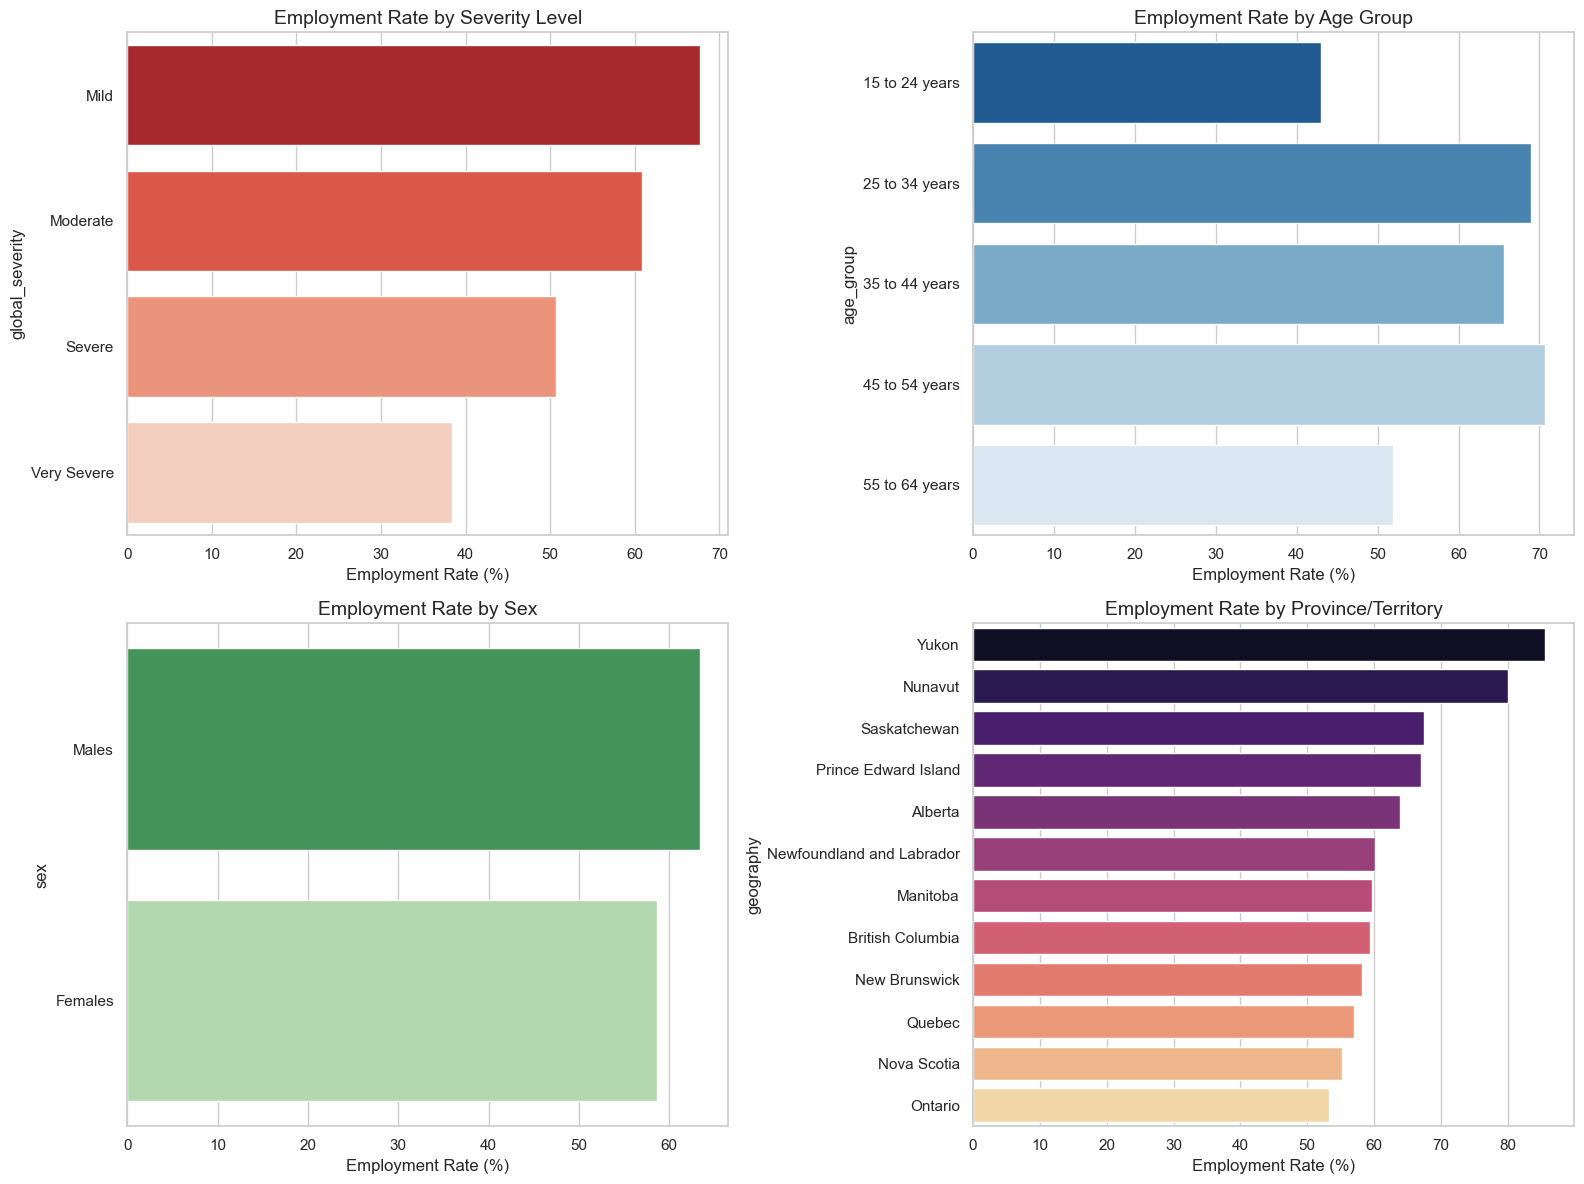

In [40]:
# Focus only on Employment Rate and looking at all disability types 
employment_rate_all_disability_types = employment_rate[employment_rate['disability_type'] == 'All disability types'].copy()

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Severity Driver
sns.barplot(
    data=employment_rate_all_disability_types, 
    x='value', 
    y='global_severity', 
    hue='global_severity', 
    ax=axes[0,0], 
    errorbar=None, 
    palette="Reds_r", 
    legend=False
)
axes[0,0].set_title('Employment Rate by Severity Level', fontsize=14)
axes[0,0].set_xlabel('Employment Rate (%)')

# 2. Age Driver
sns.barplot(
    data= employment_rate_all_disability_types, 
    x='value', 
    y='age_group', 
    hue='age_group', 
    ax=axes[0,1], 
    errorbar=None, 
    palette="Blues_r", 
    legend=False
)
axes[0,1].set_title('Employment Rate by Age Group', fontsize=14)
axes[0,1].set_xlabel('Employment Rate (%)')

# 3. Sex Driver
sns.barplot(
    data=employment_rate_all_disability_types, 
    x='value', 
    y='sex', 
    hue='sex', 
    ax=axes[1,0], 
    errorbar=None, 
    palette="Greens_r", 
    legend=False
)
axes[1,0].set_title('Employment Rate by Sex', fontsize=14)
axes[1,0].set_xlabel('Employment Rate (%)')

# 4. Location Driver (y-axis sorted by employment rate)
geo_order = (
    employment_rate_all_disability_types.groupby("geography")["value"]
    .mean()
    .sort_values(ascending=False)
    .index
)
sns.barplot(
    data=employment_rate_all_disability_types, 
    x='value', 
    y='geography', 
    hue='geography',
    order=geo_order,
    hue_order=geo_order,
    ax=axes[1,1], 
    errorbar=None, 
    palette="magma", 
    legend=False
)
axes[1,1].set_title('Employment Rate by Province/Territory', fontsize=14)
axes[1,1].set_xlabel('Employment Rate (%)')

plt.tight_layout()
plt.show()

The exploratory plots revealed some interesting trends influencing employment:

**Employment by Severity Level**: We can see a negative relationship between disability severity and employment rates. Mild impairments show employment rates near 70%, while Very Severe impairments drop significantly.

**Employment by Age Group**: We can see that employment rates follow a bell curve across age groups. The prime working ages (25-54) see the highest employment rates, whereas youth (15-24) and those nearing retirement (55-64) have much lower employment rates.

**Employment by Sex**: Males show a slightly higher employment rate than females, though the gap appears narrower than the impact of age or severity.

**Employment by Province/Territory**: While Yukon and Nunavut display high rates, their sample sizes are exceptionally small and prone to high variance. Therefore, these insights should be interpreted with caution. 

### 3. Model

To investigate which factors have the most significant impact on employment rates, we will use a combination of Machine Learning Interpretability (SHAP) and traditional statistical inference (Ordinary Least Squares).

For this phase, we filter out the generic "All disability types" category to evaluate the specific impacts of individual disability classifications (e.g., Pain, Learning, Mobility) against the demographic variables. 

The continuous target variable is the `value` column representing the percentage Employment Rate. We convert the categorical demographic features into binary indicators using one-hot encoding to prepare them for both the regression and OLS algorithms.  

In [41]:
employment_rate['disability_type'].value_counts()

disability_type
All disability types           219
Pain                           150
Flexibility                     44
Mobility                        19
Mental and/or psychological     15
Learning                         4
Hearing                          4
Name: count, dtype: int64

In [42]:
# Filter out `All disability types` from `disability_type` column
clean_employment_rate = employment_rate[employment_rate['disability_type'] != 'All disability types'].copy()

In [43]:
# Isolate features and the target
features = ['geography', 'sex', 'age_group', 'global_severity', 'disability_type']
X = pd.get_dummies(clean_employment_rate[features], drop_first=True, dtype=int)
y = clean_employment_rate['value'] 

#### Train a Regression Model

Since we are predicting a continuous numerical value (employment rate), we can use a regression model. We will choose an XGBoost Regressor for this case study because it handles non-linear relationships and complex interactions well. 

We will use a shallow depth (`max_depth=3`) to prevent overfitting.

In [44]:
reg_model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=3, 
    learning_rate=0.1, 
    random_state=42
)

reg_model.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


### 4. SHAP (SHapley Additive exPlanations)

We train an XGBoost Regressor to predict the employment rate. XGBoost is particularly effective here because tree-based models can natively capture non-linear interactions—such as the compounding effect of being both older and having a severe disability—better than strictly linear models. 

We then apply `TreeExplainer` to calculate SHAP values. Because this is a continuous regression task, the SHAP values directly represent the percentage point change in the employment rate. For example, a SHAP value of `-5.0` indicates that a specific feature reduced the predicted employment rate by 5 percentage points compared to the baseline average.

In [45]:
explainer = shap.TreeExplainer(reg_model)
shap_values = explainer(X)

A beeswarm plot is one way to visualize the SHAP values ...

This beeswarm plot shows the top 12 features and how each feature drives the prediction of the employment rate. 

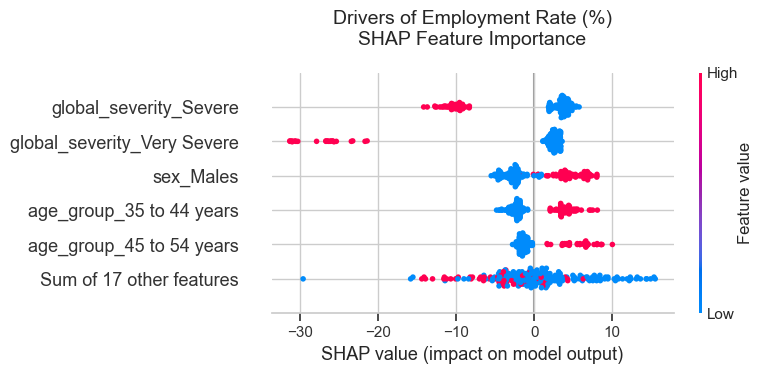

In [46]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=6, show=False)
plt.title("Drivers of Employment Rate (%)\nSHAP Feature Importance", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

#### Interpretation of the SHAP Beeswarm Plot

1. **Feature Ranking (Vertical Axis)**: Features are ordered from top to bottom by their overall magnitude of impact. Disability severity and specific age brackets dominate the top positions.

2. **Direction of Impact (Horizontal Axis)**:
    - Points to the right of the center line (0.0) represent a positive increase in the predicted employment rate.
    - Points to the left represent a decrease.

3. **Feature Value (Colour)**: Because we one-hot encoded the features (0 or 1), a red dot indicates the demographic group has that attribute, while a blue dot indicates they do not.

#### Key SHAP Takeaways

- Having a "Very Severe" or "Severe" disability (red dots) strongly pulls predictions to the left, acting as the primary drag on employment. 

- Being in the 35 to 44 or 45 to 54 age brackets acts as a strong positive driver, boosting expected employment rates by roughly 5 to 10 percentage points.

- Being male provides a slight, consistent positive bump to the prediction, suggesting a small gender gap in disability employment.

### 5. Ordinary Least Squares (OLS)

While SHAP provides good visual interpretability and captures non-linear effects, an OLS regression provides statistical validation. By extracting the p-values, we can confirm which of the drivers identified by SHAP are statistically significant at a 95% confidence level ($p < 0.05$). 

In [47]:
# Add a constant for the intercept
X_stats = sm.add_constant(X)

# Fit the OLS model
ols_model = sm.OLS(y, X_stats).fit()

# Print the statistical summary to evaluate p-values and R-squared
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.566
Method:                 Least Squares   F-statistic:                     14.93
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           4.23e-32
Time:                        23:31:39   Log-Likelihood:                -913.71
No. Observations:                 236   AIC:                             1873.
Df Residuals:                     213   BIC:                             1953.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [48]:
# Extract all p-values from the fitted model
p_values = ols_model.pvalues

# Define significance level
alpha = 0.05

# Filter for variables where the p-value is less than alpha
significant_vars = p_values[p_values < alpha]

print("Statistically Significant Features (p < 0.05):")
print(significant_vars.sort_values())

Statistically Significant Features (p < 0.05):
const                          7.022809e-38
global_severity_Very Severe    3.816896e-21
global_severity_Severe         2.970244e-15
age_group_35 to 44 years       3.264731e-06
age_group_45 to 54 years       1.022862e-05
age_group_25 to 34 years       1.783935e-05
sex_Males                      8.837103e-05
global_severity_Moderate       1.537190e-03
geography_Ontario              2.652208e-03
disability_type_Learning       2.928443e-03
geography_Nova Scotia          4.534532e-03
geography_Quebec               3.512883e-02
dtype: float64


The OLS results supported our SHAP findings:

- `global_severity_Very Severe`, `global_severity_Severe`, and the prime working age groups (25-34, 35-44, 45-54) all return p-values less than $0.05$, confirming them as the primary drivers.  

- The `sex_Males` variable is significant ($p = 8.83 \times 10^{-5}$), validating the gender gap observed in the SHAP summary.  

## Discussion

...